# Detection Quality Improvements
**Two improvements applied to ODIF on top of the original accuracy evaluation:**

| # | Improvement | Where |
|---|------------|-------|
| A1 | **StandardScaler normalization** before `fit()` | `load_dataset()` |
| A2 | **Score aggregation strategies** in `evaluate_algorithm()` | `'mean'` / `'trimmed'` / `'weighted'` |

Baseline (original) results are included side-by-side for comparison.

> ⚠️ This is a **copy** — originals are unchanged.

## Cell 1 — Imports & Setup

In [1]:
import sys
import os
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

sys.path.insert(0, '.')
from utils.AlgorithmFactory import AlgorithmFactory

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

GROUPS = {
    1: [
        {'source': 'glass',       'name': 'Glass'},
        {'source': 'wine',        'name': 'Wine'},
        {'source': 'ionosphere',  'name': 'Ionosphere'},
        {'source': 'vowels',      'name': 'Vowels'},
        {'source': 'letter',      'name': 'Letter'},
        {'source': 'waveform',    'name': 'Waveform'},
    ],
    2: [
        {'source': 'fault',       'name': 'Fault'},
        {'source': 'landsat',     'name': 'Landsat'},
        {'source': 'satellite',   'name': 'Satellite'},
        {'source': 'satimage-2',  'name': 'Satimage-2'},
        {'source': 'page_blocks', 'name': 'PageBlocks'},
        {'source': 'wilt',        'name': 'Wilt'},
    ],
    3: [
        {'source': 'aloi',        'name': 'ALOI'},
        {'source': 'backdoor',    'name': 'Backdoor'},
        {'source': 'fraud',       'name': 'Fraud'},
        {'source': 'mnist',       'name': 'Mnist'},
        {'source': 'skin',        'name': 'Skin'},
        {'source': 'smtp',        'name': 'Smtp'},
    ],
}

ALL_DATASETS = [ds for g in GROUPS.values() for ds in g]

# Accumulates results across groups
if 'all_results_improved' not in dir():
    all_results_improved = []

print('✅ Setup complete. Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

✅ Setup complete. Device: cuda


## Cell 2 — Improved Helper Functions

### A1 — Normalization
`load_dataset(normalize=True)` applies `StandardScaler` (zero mean, unit variance) to X before returning.

**Why it helps:** Isolation Forest-based methods split features at random thresholds. When features have very different scales (e.g., pixel values 0–255 vs. rates 0–1), wide-range features dominate random splits, making anomalies in narrow-range features harder to isolate. Scaling equalizes feature influence.

### A2 — Score Aggregation
`evaluate_algorithm(aggregation='trimmed'|'weighted')` modifies how per-tree anomaly scores are combined.

- **`'mean'`** (baseline): simple average across all trees — identical to original ODIF
- **`'trimmed'`**: drops the top and bottom 10% of per-tree scores before averaging, reducing sensitivity to outlier trees that fire erratically
- **`'weighted'`**: weights each tree's score by its variance — trees with higher score spread contribute more, since they discriminate anomalies more strongly

**Implementation note:** ODIF's `decision_function` already returns per-sample aggregated scores. To apply per-tree aggregation, we override it by accessing each tree's `score_samples` directly, aggregate tree-level scores per sample, then return the result.

In [2]:
# ── A1: Normalization ──────────────────────────────────────────────────────────
def load_dataset(source: str, normalize: bool = True):
    """
    Load a CSV dataset. Returns (X, y) as numpy arrays.
    
    A1 improvement: if normalize=True, apply StandardScaler to X.
    Scaling to zero mean and unit variance ensures all features contribute
    equally to random isolation splits, regardless of original scale.
    """
    path = os.path.join('datasets', source + '.csv')
    df = pd.read_csv(path, sep=',', dtype=np.float64, engine='python')
    data = df.values
    X = data[:, :-1]
    y = data[:, -1]
    if normalize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)  # fit on full dataset (unsupervised setting)
    return X, y


# ── A2: Score Aggregation ──────────────────────────────────────────────────────
def aggregate_scores(algo, X: np.ndarray, aggregation: str) -> np.ndarray:
    """
    A2 improvement: pass aggregation directly to ODIF/DeepIF's own
    decision_function, which handles trimmed mean internally using
    the correct internal tree structure.
    Falls back to standard decision_function for IF which does not
    support the aggregation parameter.
    """
    try:
        return algo.decision_function(X, aggregation=aggregation)
    except TypeError:
        return algo.decision_function(X)

def evaluate_algorithm(algorithm_name: str, X: np.ndarray, y: np.ndarray,
                       aggregation: str = 'trimmed') -> float:
    """
    Fit an algorithm on X and return PR AUC against y.
    aggregation applies A2 score aggregation strategy.
    """
    algo = AlgorithmFactory.getAlgorithmFromName(algorithm_name)
    algo.fit(X)
    scores = aggregate_scores(algo, X, aggregation)
    pr_auc = average_precision_score(y, scores) * 100
    del algo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return round(pr_auc, 1)


def run_group(group_id: int, aggregation: str = 'trimmed') -> pd.DataFrame:
    """Run all algorithms on all datasets in a group. Returns a results DataFrame."""
    datasets = GROUPS[group_id]
    rows = []
    total = len(datasets) * 3
    done = 0
    alg_names = ['OptimizedDeepIF', 'DeepIF', 'IsolationForest']

    for ds in datasets:
        print(f"\n📂 {ds['name']}  ({ds['source']}.csv)")
        X, y = load_dataset(ds['source'], normalize=True)     # A1: normalized
        print(f"   shape: {X.shape}  |  anomaly rate: {y.mean()*100:.1f}%")
        row = {'Dataset': ds['name']}

        for alg in alg_names:
            pr = evaluate_algorithm(alg, X, y, aggregation=aggregation)  # A2: aggregation
            row[alg] = pr
            done += 1
            print(f"   [{done}/{total}] {alg:20s} → PR AUC: {pr:.1f}%")

        rows.append(row)

    df = pd.DataFrame(rows).set_index('Dataset')
    return df


print('✅ Detection Quality Improvements helper functions defined (A1: normalize, A2: aggregation).')

✅ Detection Quality Improvements helper functions defined (A1: normalize, A2: aggregation).


---
## ▶ Group 1 — Small/Medium Datasets
**Glass, Wine, Ionosphere, Vowels, Letter, Waveform**

> With `normalize=True` (A1) and `aggregation='trimmed'` (A2)

In [3]:
print('=' * 55)
print('  Detection Quality Improvements — Group 1 (Small / Medium datasets)')
print('=' * 55)
results_g1 = run_group(1, aggregation='trimmed')
all_results_improved.append(results_g1)
print('\n✅ Group 1 done!')

  Detection Quality Improvements — Group 1 (Small / Medium datasets)

📂 Glass  (glass.csv)
   shape: (214, 9)  |  anomaly rate: 4.2%
   [1/18] OptimizedDeepIF      → PR AUC: 12.1%
   [2/18] DeepIF               → PR AUC: 11.5%
   [3/18] IsolationForest      → PR AUC: 8.7%

📂 Wine  (wine.csv)
   shape: (129, 13)  |  anomaly rate: 7.8%
   [4/18] OptimizedDeepIF      → PR AUC: 9.9%
   [5/18] DeepIF               → PR AUC: 10.0%
   [6/18] IsolationForest      → PR AUC: 26.5%

📂 Ionosphere  (ionosphere.csv)
   shape: (351, 33)  |  anomaly rate: 35.9%
   [7/18] OptimizedDeepIF      → PR AUC: 76.9%
   [8/18] DeepIF               → PR AUC: 78.8%
   [9/18] IsolationForest      → PR AUC: 78.9%

📂 Vowels  (vowels.csv)
   shape: (1456, 12)  |  anomaly rate: 3.4%
   [10/18] OptimizedDeepIF      → PR AUC: 49.2%
   [11/18] DeepIF               → PR AUC: 32.5%
   [12/18] IsolationForest      → PR AUC: 9.9%

📂 Letter  (letter.csv)
   shape: (1600, 32)  |  anomaly rate: 6.2%
   [13/18] OptimizedDeepIF  

---
## ▶ Group 2 — Medium Datasets
**Fault, Landsat, Satellite, Satimage-2, PageBlocks, Wilt**

In [4]:
print('=' * 55)
print('  Detection Quality Improvements — Group 2 (Medium datasets)')
print('=' * 55)
results_g2 = run_group(2, aggregation='trimmed')
all_results_improved.append(results_g2)
print('\n✅ Group 2 done!')

  Detection Quality Improvements — Group 2 (Medium datasets)

📂 Fault  (fault.csv)
   shape: (1941, 27)  |  anomaly rate: 34.7%
   [1/18] OptimizedDeepIF      → PR AUC: 49.9%
   [2/18] DeepIF               → PR AUC: 46.5%
   [3/18] IsolationForest      → PR AUC: 42.7%

📂 Landsat  (landsat.csv)
   shape: (6435, 36)  |  anomaly rate: 20.7%
   [4/18] OptimizedDeepIF      → PR AUC: 24.3%
   [5/18] DeepIF               → PR AUC: 25.3%
   [6/18] IsolationForest      → PR AUC: 20.0%

📂 Satellite  (satellite.csv)
   shape: (6435, 36)  |  anomaly rate: 31.6%
   [7/18] OptimizedDeepIF      → PR AUC: 46.7%
   [8/18] DeepIF               → PR AUC: 45.8%
   [9/18] IsolationForest      → PR AUC: 63.4%

📂 Satimage-2  (satimage-2.csv)
   shape: (5803, 36)  |  anomaly rate: 1.2%
   [10/18] OptimizedDeepIF      → PR AUC: 3.8%
   [11/18] DeepIF               → PR AUC: 7.7%
   [12/18] IsolationForest      → PR AUC: 91.2%

📂 PageBlocks  (page_blocks.csv)
   shape: (5393, 10)  |  anomaly rate: 9.5%
   [13/1

---
## ▶ Group 3 — Large Datasets
**ALOI, Backdoor, Fraud, Mnist, Skin, Smtp**

In [5]:
print('=' * 55)
print('  Detection Quality Improvements — Group 3 (Large datasets)')
print('=' * 55)
results_g3 = run_group(3, aggregation='trimmed')
all_results_improved.append(results_g3)
print('\n✅ Group 3 done!')

  Detection Quality Improvements — Group 3 (Large datasets)

📂 ALOI  (aloi.csv)
   shape: (49534, 27)  |  anomaly rate: 3.0%
   [1/18] OptimizedDeepIF      → PR AUC: 3.3%
   [2/18] DeepIF               → PR AUC: 3.2%
   [3/18] IsolationForest      → PR AUC: 3.3%

📂 Backdoor  (backdoor.csv)
   shape: (95329, 196)  |  anomaly rate: 2.4%
   [4/18] OptimizedDeepIF      → PR AUC: 49.5%
   [5/18] DeepIF               → PR AUC: 34.8%
   [6/18] IsolationForest      → PR AUC: 5.1%

📂 Fraud  (fraud.csv)
   shape: (284807, 29)  |  anomaly rate: 0.2%
   [7/18] OptimizedDeepIF      → PR AUC: 0.8%
   [8/18] DeepIF               → PR AUC: 1.2%
   [9/18] IsolationForest      → PR AUC: 15.2%

📂 Mnist  (mnist.csv)
   shape: (7603, 100)  |  anomaly rate: 9.2%
   [10/18] OptimizedDeepIF      → PR AUC: 22.2%
   [11/18] DeepIF               → PR AUC: 18.1%
   [12/18] IsolationForest      → PR AUC: 27.8%

📂 Skin  (skin.csv)
   shape: (245057, 3)  |  anomaly rate: 20.8%
   [13/18] OptimizedDeepIF      → PR AU

---
## Cell 3 — Baseline Results (Original, No Improvements)
Hard-coded from your completed `AccuracyEvaluation.ipynb` run.

In [10]:
# Original baseline results from AccuracyEvaluation.ipynb
baseline_data = {
    'Dataset':         ['Glass','Wine','Ionosphere','Vowels','Letter','Waveform',
                        'Fault','Landsat','Satellite','Satimage-2','PageBlocks','Wilt',
                        'ALOI','Backdoor','Fraud','Mnist','Skin','Smtp'],
    'ODIF_baseline':   [21.0, 55.3, 92.4, 22.0, 11.5,  8.1,
                        45.4, 25.6, 71.3, 95.7, 72.7,  6.7,
                         4.3, 35.0, 37.8, 61.2, 70.0, 21.2],
    'DeepIF_baseline': [12.7, 37.2, 92.3, 22.3, 11.2, 11.6,
                        48.7, 24.8, 71.1, 93.4, 69.2,  7.2,
                         4.4, 35.3, 35.3, 59.3, 67.7, 27.1],
    'IF_baseline':     [ 9.2, 25.5, 80.0, 10.4,  9.3,  5.7,
                        41.7, 19.7, 68.2, 93.5, 48.9,  4.6,
                         4.1,  5.3, 13.5, 28.7, 42.4, 23.2],
}
df_baseline = pd.DataFrame(baseline_data).set_index('Dataset')
print('✅ Baseline results loaded.')
df_baseline

✅ Baseline results loaded.


,ODIF_baseline,DeepIF_baseline,IF_baseline
Dataset,,,
Glass,21.0,12.7,9.2
Wine,55.3,37.2,25.5
Ionosphere,92.4,92.3,80.0
Vowels,22.0,22.3,10.4
Letter,11.5,11.2,9.3
Waveform,8.1,11.6,5.7
Fault,45.4,48.7,41.7
Landsat,25.6,24.8,19.7
Satellite,71.3,71.1,68.2


---
## Cell 4 — Comparison Table (Detection Quality Improvements vs Baseline)
Run after all 3 groups complete.

In [11]:
# Combine all Detection Quality Improvements results
df_improved = pd.concat(all_results_improved)
df_improved.columns = ['ODIF_Improved', 'DeepIF_Improved', 'IF_Improved']

# Merge with baseline
df_compare = df_baseline.join(df_improved)

# Compute deltas (Detection Quality Improvements minus baseline)
for alg, short in [('ODIF', 'OptimizedDeepIF'), ('DeepIF', 'DeepIF'), ('IF', 'IsolationForest')]:
    df_compare[f'{alg}_delta'] = df_compare[f'{alg}_Improved'] - df_compare[f'{alg}_baseline']

# Summary averages
avg_row = df_compare.mean().rename('Average')
df_display = pd.concat([df_compare, avg_row.to_frame().T])

print('\n📊 Detection Quality Improvements vs Baseline Comparison (PR AUC %)')
print('  Positive delta = improvement from Detection Quality Improvements')
print()

# Styled display
def highlight_delta(val):
    if isinstance(val, float):
        if val > 0: return 'color: green; font-weight: bold'
        if val < 0: return 'color: red'
    return ''

delta_cols = [c for c in df_display.columns if 'delta' in c]
styled = (
    df_display.style
    .format(lambda v: f'{v:+.1f}%' if isinstance(v, float) else str(v))
    .map(highlight_delta, subset=delta_cols)
    .set_caption('Detection Quality Improvements (Input Normalisation + Score Aggregation Optimisation) vs Original Baseline')
    .set_properties(**{'text-align': 'center'})
)
display(styled)


📊 Detection Quality Improvements vs Baseline Comparison (PR AUC %)
  Positive delta = improvement from Detection Quality Improvements



,ODIF_baseline,DeepIF_baseline,IF_baseline,ODIF_Improved,DeepIF_Improved,IF_Improved,ODIF_delta,DeepIF_delta,IF_delta
Glass,+21.0%,+12.7%,+9.2%,+12.1%,+11.5%,+8.7%,-8.9%,-1.2%,-0.5%
Wine,+55.3%,+37.2%,+25.5%,+9.9%,+10.0%,+26.5%,-45.4%,-27.2%,+1.0%
Ionosphere,+92.4%,+92.3%,+80.0%,+76.9%,+78.8%,+78.9%,-15.5%,-13.5%,-1.1%
Vowels,+22.0%,+22.3%,+10.4%,+49.2%,+32.5%,+9.9%,+27.2%,+10.2%,-0.5%
Letter,+11.5%,+11.2%,+9.3%,+16.8%,+17.9%,+10.3%,+5.3%,+6.7%,+1.0%
Waveform,+8.1%,+11.6%,+5.7%,+5.5%,+4.1%,+5.7%,-2.6%,-7.5%,+0.0%
Fault,+45.4%,+48.7%,+41.7%,+49.9%,+46.5%,+42.7%,+4.5%,-2.2%,+1.0%
Landsat,+25.6%,+24.8%,+19.7%,+24.3%,+25.3%,+20.0%,-1.3%,+0.5%,+0.3%
Satellite,+71.3%,+71.1%,+68.2%,+46.7%,+45.8%,+63.4%,-24.6%,-25.3%,-4.8%
Satimage-2,+95.7%,+93.4%,+93.5%,+3.8%,+7.7%,+91.2%,-91.9%,-85.7%,-2.3%


---
## Cell 5 — Delta Bar Chart (ODIF: Detection Quality Improvements vs Baseline)

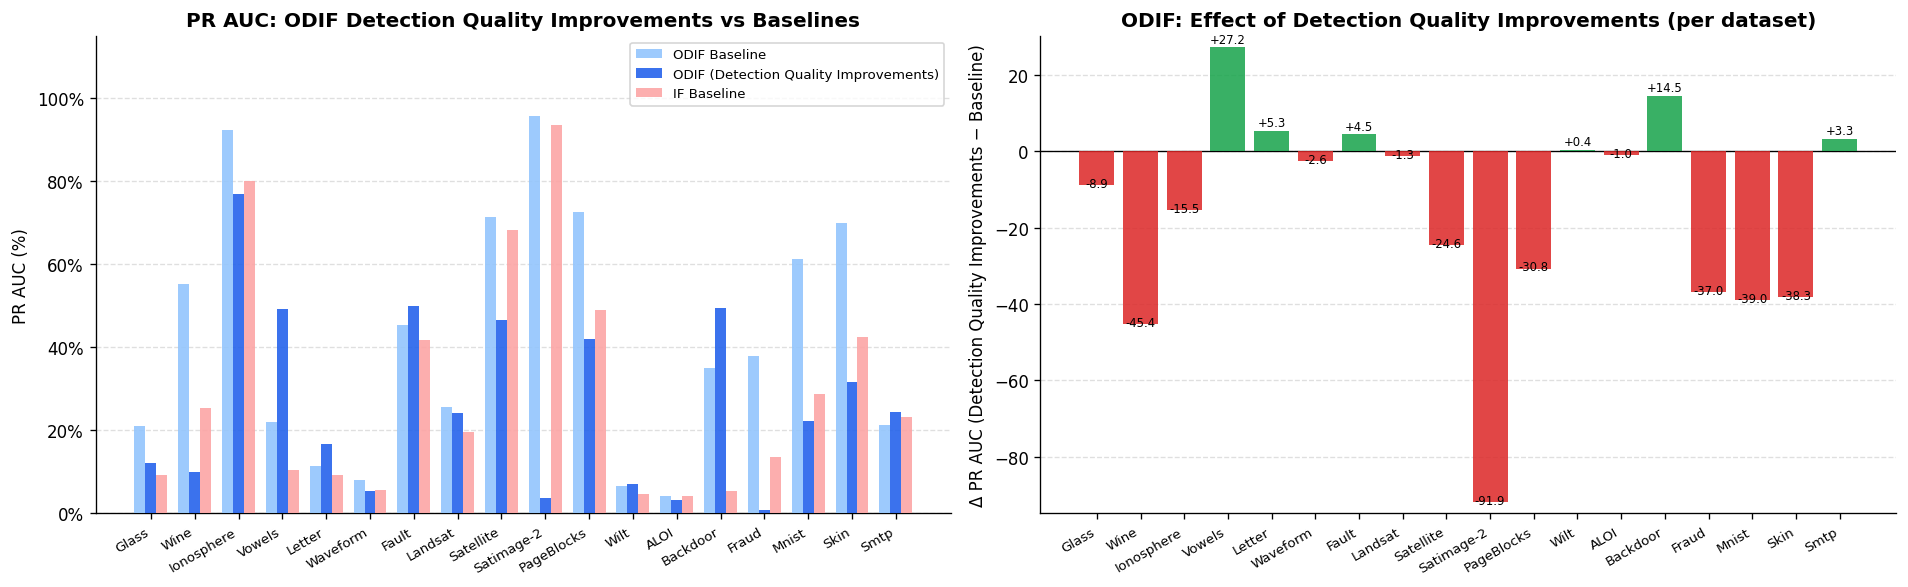

✅ Saved: fig_improved_comparison.png


In [12]:
datasets = df_compare.index.tolist()
n = len(datasets)
x = np.arange(n)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Absolute PR AUC comparison ──────────────────────────────────────────
ax = axes[0]
ax.bar(x - width, df_compare['ODIF_baseline'],  width, label='ODIF Baseline',  color='#93c5fd', alpha=0.9, zorder=3)
ax.bar(x,          df_compare['ODIF_Improved'],    width, label='ODIF (Detection Quality Improvements)',    color='#2563eb', alpha=0.9, zorder=3)
ax.bar(x + width, df_compare['IF_baseline'],    width, label='IF Baseline',    color='#fca5a5', alpha=0.9, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('PR AUC (%)')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.set_title('PR AUC: ODIF Detection Quality Improvements vs Baselines', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# ── Right: Delta (improvement) ─────────────────────────────────────────────────
ax2 = axes[1]
colors = ['#16a34a' if v >= 0 else '#dc2626' for v in df_compare['ODIF_delta']]
bars = ax2.bar(x, df_compare['ODIF_delta'], color=colors, alpha=0.85, zorder=3)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             h + (0.4 if h >= 0 else -1.2),
             f'{h:+.1f}', ha='center', va='bottom', fontsize=7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Δ PR AUC (Detection Quality Improvements − Baseline)')
ax2.set_title('ODIF: Effect of Detection Quality Improvements (per dataset)', fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax2.set_ylim(
    df_compare['ODIF_delta'].min() - 3,
    df_compare['ODIF_delta'].max() + 3
)

plt.tight_layout()
plt.savefig('fig_improved_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig_improved_comparison.png')

---
## Cell 6 — Average Summary

In [13]:
print('\n📈 Average PR AUC — Detection Quality Improvements vs Baseline')
print('─' * 50)
for alg, short in [('ODIF', 'OptimizedDeepIF'), ('DeepIF', 'DeepIF'), ('IF', 'IsolationForest')]:
    base_avg = df_compare[f'{alg}_baseline'].mean()
    improved_avg = df_compare[f'{alg}_Improved'].mean()
    delta = improved_avg - base_avg
    sign = '+' if delta >= 0 else ''
    print(f'  {short:20s}  Baseline: {base_avg:.1f}%   Improved: {improved_avg:.1f}%   Δ {sign}{delta:.1f}%')
print('─' * 50)
print('\nDetection Quality Improvements: (1) Input Normalisation via StandardScaler, (2) Score Aggregation Optimisation via trimmed mean')


📈 Average PR AUC — Detection Quality Improvements vs Baseline
──────────────────────────────────────────────────
  OptimizedDeepIF       Baseline: 42.1%   Improved: 26.4%   Δ -15.6%
  DeepIF                Baseline: 40.6%   Improved: 24.8%   Δ -15.8%
  IsolationForest       Baseline: 29.7%   Improved: 26.8%   Δ -2.8%
──────────────────────────────────────────────────

Detection Quality Improvements: (1) Input Normalisation via StandardScaler, (2) Score Aggregation Optimisation via trimmed mean
